In [13]:
# set notebook's root to enclosing folder
import os, sys, platform
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(ROOT_DIR)

from omegaconf import OmegaConf, DictConfig
import numpy as np
import pandas as pd
import torch

# set data path for cluster and mac
node = platform.node()
if "arctrd" in node:
    DATA_ROOT = "/data/users2/ppopov1/datasets"
elif "URSMWJ" in node:  # mac
    DATA_ROOT = "/Users/ppopov1/datasets"
else:
    DATA_ROOT = ROOT_DIR.joinpath("assets/data")

# load UKB data

In [ ]:
from src.datasets.ukb_hold import load_data_hold as load_ukb_pretrain

UKB_DATADICT, demo_df = load_ukb_pretrain(
    file_path=os.path.join(DATA_ROOT, "ukb_ica/ukb_data_hold.npz"),
    demo_path=os.path.join(DATA_ROOT, "ukb_ica/demographics_legend_hold.csv"),
)

UKB_DATA = UKB_DATADICT['data']
print("Available data in ukb datadict:",UKB_DATADICT.keys())
# prepare train and validation sets
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(UKB_DATA, test_size=0.2, random_state=42)

Available data in ukb datadict: dict_keys(['data', 'sexes', 'ages', 'age_bins'])


# test model

In [ ]:
# set model config

from src.models.DECIFRA import default_HPs

cfg = {
    "data_info": {
        "feature_size": UKB_DATA.shape[2],
        "n_classes": 2,
        }
    }
cfg = OmegaConf.create(cfg)

model_cfg = default_HPs(cfg)
# reconfigure loss weights
model_cfg.loss.sp_weight = 0.5
model_cfg.loss.forecast_weight = 1.0
model_cfg.pretraining = True

print(OmegaConf.to_yaml(model_cfg))

rnn:
  input_embedding_size: 16
  hidden_size: 16
btp:
  hidden_dim: 16
loss:
  threshold: 0.01
  sp_weight: 0.5
  forecast_weight: 1.0
lr: 0.0001
load_pretrained: false
pretrained_path: null
input_size: 53
output_size: 2



## pytorch lightning

In [7]:
# lightning_decifra
import torch
from lightning.pytorch import LightningModule

from src.models.DECIFRA import DECIFRA
from src.models.BaseModel import compute_metrics

class LitDECIFRA_pretraining(LightningModule):
    """
    Thin Lightning wrapper that reuses your DECIFRA exactly as-is.
    Supports both pretraining (forecasting + sparsity) and classification.
    """
    def __init__(self, model: DECIFRA):
        super().__init__()
        self.model = model
        
        # optional: keeps lr/pretraining flag in hparams (safe to store small scalars)
        self.save_hyperparameters(model.model_cfg)

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        # Reuse your model's optimizer factory
        return self.model.get_optimizer(self.model.lr)

    def _step(self, batch, stage: str):
        x = batch[0].to(self.device)
        _, loss_load = self.model(x)
        loss, log = self.model.compute_loss(loss_load, None)
        
        # Lightning logging (averaged over epoch)
        pref = f"{stage}_"
        # NOTE: 'loss' must be logged as a tensor for proper reduce/monitor
        self.log(f"{pref}loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        # other scalars can be floats
        self.log_dict({pref + k: float(v) for k, v in log.items()},
                      on_step=False, on_epoch=True, prog_bar=(stage == "val"))
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._step(batch, "val")


In [8]:
#training

import os
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

from src.models.DECIFRA import DECIFRA

import time

LOGS_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../assets/logs/1_pretraining/"))
os.makedirs(LOGS_ROOT, exist_ok=True)

# build model
model = DECIFRA(model_cfg)
lit_model = LitDECIFRA_pretraining(model)

# dataloaders you already have (TS_only)
train_loader = DECIFRA.prepare_pretraining_dataloader(train_data, shuffle=True,  batch_size=64)
val_loader   = DECIFRA.prepare_pretraining_dataloader(val_data,   shuffle=False, batch_size=64)

# set up save path
utc_string = time.strftime("%m%d-%H%M%S", time.gmtime())
save_path = f"1_pretrain_{model.__class__.__name__}_{utc_string}"
save_path = os.path.join(LOGS_ROOT, save_path)

# callbacks, logging, ckpt on best val_loss
logger = CSVLogger(save_dir=save_path, name="train_logs")
ckpt   = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=-1, filename="model_{epoch:03d}-val_loss{val_loss:.4f}")
lrm    = LearningRateMonitor(logging_interval="epoch")

trainer = Trainer(
    max_epochs=200,
    accelerator="auto", devices=1,  # will use mps/cuda/cpu automatically
    logger=logger,
    callbacks=[ckpt, lrm],
)

trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

print("Best checkpoint:", ckpt.best_model_path)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type    | Params | Mode 
------------------------------------------
0 | model | DECIFRA | 4.9 M  | train
------------------------------------------
4.9 M     Trainable params
0         Non-trainable params
4.9 M     Total params
19.756    Total estimated model params size (MB)
25        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/ppopov1/miniconda3/envs/pile/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/ppopov1/miniconda3/envs/pile/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/ppopov1/miniconda3/envs/pile/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (15) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/Users/ppopov1/miniconda3/envs/pile/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3675: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## my training script

In [16]:
# trainer class
import time
from copy import deepcopy

LOGS_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../assets/logs/1_pretraining/'))

class BasicTrainer:

    def __init__(
        self,
        cfg,
        model_cfg,
        model,
        optimizer,
        train_loader,
        val_loader,
        epochs: int = 100,
        device: str = None,
        patience: int = 30,
    ) -> None:
        
        self.cfg = cfg
        self.model_cfg = model_cfg

        self.model = model
        self.optimizer = optimizer

        self.train_loader = train_loader
        self.val_loader = val_loader

        self.epochs = epochs
        if device is not None:
            self.device = torch.device(device)
        else:
            self.device = torch.device("cuda") if torch.cuda.is_available() \
                else torch.device("mps") if torch.backends.mps.is_available() \
                    else torch.device("cpu")
            
        # move model to device
        self.model.to(self.device)


    def _epoch(self, loader, train: bool):
        with torch.set_grad_enabled(train):
            self.model.train(train)
            total_loss = 0.0
            n_batches = len(loader)
            agg_log = {}

            for batch in loader:
                # batch = tuple(t.to(self.device) for t in batch) # cast batch to device
                # loss, batch_log = self.model.handle_batch(batch)

                batch = [b.to(self.device) for b in batch]
                _, loss_load = self.model(*batch)
                loss, batch_log = self.model.compute_loss(loss_load, None)

                total_loss += float(loss.detach().cpu().item())

                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()

                for k, v in batch_log.items():
                    if isinstance(v, (int, float)):
                        agg_log[k] = agg_log.get(k, 0.0) + float(v)

            # average logs over batches
            agg_log = {k: v / n_batches for k, v in agg_log.items()}
            agg_log["loss"] = total_loss / n_batches
            return agg_log

    def run(self):
        # set save path, save config
        utc_string = time.strftime("%m%d-%H%M%S", time.gmtime())
        logs_path = f"1_pretrain_{self.model.__class__.__name__}_{utc_string}"
        logs_path = os.path.join(LOGS_ROOT, logs_path)
        checkpoints_path = os.path.join(logs_path, "checkpoints")
        os.makedirs(logs_path, exist_ok=True)
        os.makedirs(checkpoints_path, exist_ok=True)
        with open(os.path.join(logs_path, "model_config.yaml"), "w") as f:
            OmegaConf.save(config=self.model_cfg, f=f.name)
        with open(os.path.join(logs_path, "config.yaml"), "w") as f:
            OmegaConf.save(config=self.cfg, f=f.name)

        ### Training loop
        train_logs = []
        start = time.time()
        torch.save(self.model.state_dict(), os.path.join(logs_path, "model_init.pt"))
        for epoch in range(self.epochs):
            print(f"Epoch {epoch+1}/{self.epochs} | Elapsed time: {time.time()-start:.0f}s")
            train_log = self._epoch(self.train_loader, train=True)
            val_log = self._epoch(self.val_loader, train=False)

            torch.save(self.model.state_dict(), os.path.join(checkpoints_path, f"model_{epoch}.pt"))

            # handle logs
            epoch_log = {"model": self.model.__class__.__name__, "epoch": epoch}
            epoch_log.update({f"train_{k}": v for k, v in train_log.items()})
            epoch_log.update({f"val_{k}": v for k, v in val_log.items()})
            train_logs.append(epoch_log)

            print(epoch_log)

        # find best epoch
        train_logs = pd.DataFrame(train_logs)
        best_epoch = train_logs['val_loss'].idxmin()
        with open(os.path.join(logs_path, "best_epoch.txt"), "w") as f:
            f.write(f"{best_epoch}\n")
        
        # build train history DataFrame
        train_logs = pd.DataFrame(train_logs)
        train_logs.to_csv(os.path.join(logs_path, "train_logs.csv"), index=False)

        return train_logs

In [5]:
# train
from src.models.DECIFRA import DECIFRA
import torch
device = torch.device("mps")

model = DECIFRA(model_cfg)
model = model.to(device)
optimizer = model.get_optimizer()
model.train()

model.pretraining
# train_dataloader = model.prepare_pretraining_dataloader(train_data, shuffle=True)
# val_dataloader = model.prepare_pretraining_dataloader(val_data, shuffle=False)

# trainer = BasicTrainer(
#     cfg=cfg,
#     model_cfg=model_cfg,
#     model=model,
#     optimizer=optimizer,
#     train_loader=train_dataloader,
#     val_loader=val_dataloader,
# )

# train_logs = trainer.run()

False

## simple training script

In [ ]:
# simpler function

from src.models.DECIFRA import DECIFRA, default_HPs
import torch
device = torch.device("mps")

model = DECIFRA(model_cfg)
model = model.to(device)
optimizer = model.get_optimizer()
model.train()

dataloader = DECIFRA.prepare_pretraining_dataloader(UKB_DATA, batch_size=32, shuffle=True)

logs = []
for epoch in range(100):
    print(f"Epoch {epoch+1}/100")
    epoch_logs = []
    for batch in dataloader:
        batch = [b.to(device) for b in batch]
        logits, loss_load = model(*batch)
        loss, loss_log = model.compute_loss(loss_load, None)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_logs.append(loss_log)
    epoch_logs = {k: sum(d[k] for d in epoch_logs)/len(epoch_logs) for k in epoch_logs[0]}
    logs.append(epoch_logs)
    print(epoch_logs)

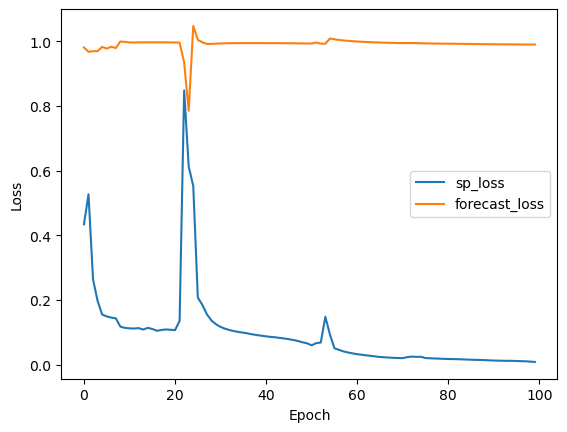

In [11]:
logs_df = pd.DataFrame(logs)

# plot sp_loss and forecast_loss
import matplotlib.pyplot as plt
plt.plot(logs_df['sp_loss'], label='sp_loss')
plt.plot(logs_df['forecast_loss'], label='forecast_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()